In [22]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [23]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [24]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,age_18_29_share,elderly_share,black_share,hispanic_share
0,BALDWIN,207643,122542,0.5902,0.0634,253507.0,10.0,8.268600,32.797637,0.096326,0.480902,0.049934,0.011110
1,BARBOUR,17666,9919,0.5615,0.0598,24585.0,25.5,22.186295,11.464715,0.096326,0.480902,0.381073,0.005050
2,BULLOCK,7181,4144,0.5771,0.0980,9897.0,33.6,25.955544,8.999729,0.106456,0.484044,0.722533,0.004385
3,BUTLER,14530,8530,0.5871,0.0544,18382.0,23.6,12.405044,13.764813,0.098743,0.474606,0.369576,0.002219
4,CHOCTAW,10767,6692,0.6215,0.0675,12252.0,24.8,15.781285,13.914203,0.113017,0.489992,0.366441,0.001204


In [25]:
candidate_features = [
    # core
    "turnout_rate",
    "poverty_rate",
    "pct_less_hs",

    # demographic vulnerability
    "black_share",
    "hispanic_share",
    "age_18_29_share",
    "elderly_share"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,black_share,hispanic_share,age_18_29_share,elderly_share
0,0.5902,10.0,8.268600,0.049934,0.011110,0.096326,0.480902
1,0.5615,25.5,22.186295,0.381073,0.005050,0.096326,0.480902
2,0.5771,33.6,25.955544,0.722533,0.004385,0.106456,0.484044
3,0.5871,23.6,12.405044,0.369576,0.002219,0.098743,0.474606
4,0.6215,24.8,15.781285,0.366441,0.001204,0.113017,0.489992


In [26]:
pca_df.describe()

,turnout_rate,poverty_rate,pct_less_hs,black_share,hispanic_share,age_18_29_share,elderly_share
count,25.000000,24.000000,24.000000,25.000000,25.000000,25.000000,25.000000
mean,0.575536,24.416667,15.467159,0.459722,0.004119,0.109385,0.465528
std,0.047023,6.375747,4.094101,0.208375,0.003780,0.013617,0.029073
min,0.446800,10.000000,8.268600,0.049934,0.000750,0.085848,0.406123
25%,0.551600,19.075000,12.414252,0.318519,0.001418,0.098743,0.451023
50%,0.588500,23.700000,15.256294,0.396576,0.002967,0.107438,0.470767
75%,0.615700,29.800000,17.557432,0.662723,0.004449,0.115842,0.485890
max,0.626500,33.800000,25.955544,0.784920,0.015787,0.150505,0.510965


In [27]:
# turnout: lower turnout = higher risk
pca_df["turnout_rate"] = 1 - pca_df["turnout_rate"]

# education
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100
    
# poverty
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,black_share,hispanic_share,age_18_29_share,elderly_share
0,0.4098,0.100,0.082686,0.049934,0.011110,0.096326,0.480902
1,0.4385,0.255,0.221863,0.381073,0.005050,0.096326,0.480902
2,0.4229,0.336,0.259555,0.722533,0.004385,0.106456,0.484044
3,0.4129,0.236,0.124050,0.369576,0.002219,0.098743,0.474606
4,0.3785,0.248,0.157813,0.366441,0.001204,0.113017,0.489992


In [28]:
pca_df.isna().sum()

turnout_rate       0
poverty_rate       1
pct_less_hs        1
black_share        0
hispanic_share     0
age_18_29_share    0
elderly_share      0
dtype: int64

In [29]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,turnout_rate,poverty_rate,pct_less_hs,black_share,hispanic_share,age_18_29_share,elderly_share
0,0.4098,0.100,0.082686,0.049934,0.011110,0.096326,0.480902
1,0.4385,0.255,0.221863,0.381073,0.005050,0.096326,0.480902
2,0.4229,0.336,0.259555,0.722533,0.004385,0.106456,0.484044
3,0.4129,0.236,0.124050,0.369576,0.002219,0.098743,0.474606
4,0.3785,0.248,0.157813,0.366441,0.001204,0.113017,0.489992


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [31]:
corr = X_imputed.corr()
corr

,turnout_rate,poverty_rate,pct_less_hs,black_share,hispanic_share,age_18_29_share,elderly_share
turnout_rate,1.000000,-0.011891,-0.120380,0.168897,0.485673,0.134262,-0.211548
poverty_rate,-0.011891,1.000000,0.554505,0.816047,-0.532893,-0.319343,0.565786
pct_less_hs,-0.120380,0.554505,1.000000,0.411939,-0.265621,-0.132724,0.241912
black_share,0.168897,0.816047,0.411939,1.000000,-0.360002,-0.344107,0.499955
hispanic_share,0.485673,-0.532893,-0.265621,-0.360002,1.000000,0.152847,-0.530687
age_18_29_share,0.134262,-0.319343,-0.132724,-0.344107,0.152847,1.000000,-0.771443
elderly_share,-0.211548,0.565786,0.241912,0.499955,-0.530687,-0.771443,1.000000


In [32]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [33]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.468561,0.468561
1,PC2,0.195429,0.663990
2,PC3,0.161262,0.825252
3,PC4,0.095390,0.920642
4,PC5,0.042405,0.963047
5,PC6,0.020643,0.983690
6,PC7,0.016310,1.000000


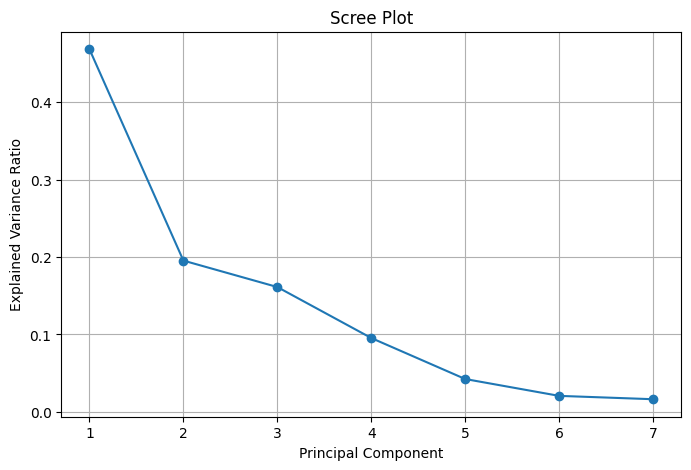

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [35]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
turnout_rate,-0.129753,0.752555,-0.211241,-0.190181,0.558771,-0.059626,-0.142314
poverty_rate,0.480680,0.248243,0.206779,-0.142695,-0.176731,0.742951,-0.246966
pct_less_hs,0.313893,0.167673,0.458837,0.749689,0.267614,-0.166513,0.038062
black_share,0.430638,0.405116,0.050226,-0.245905,-0.514855,-0.529793,0.204165
hispanic_share,-0.374636,0.381489,-0.311944,0.469370,-0.441748,0.298252,0.335264
age_18_29_share,-0.339370,0.102063,0.666888,-0.315208,0.083949,0.142272,0.550479
elderly_share,0.461095,-0.154441,-0.396885,-0.036090,0.343015,0.163907,0.678376


In [36]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-2.654562
1,BARBOUR,0.906565
2,BULLOCK,2.468979
3,BUTLER,0.146300
4,CHOCTAW,0.589376


In [37]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,1.808835
1,BARBOUR,66.827065
2,BULLOCK,95.353253
3,BUTLER,52.946323
4,CHOCTAW,61.035899


In [38]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
10,GREENE,100.000000
21,SUMTER,97.217858
2,BULLOCK,95.353253
18,PERRY,89.070495
23,WILCOX,87.755482
12,LOWNDES,85.868631
8,DALLAS,79.060590
13,MACON,70.984504
1,BARBOUR,66.827065
6,CONECUH,64.922146


In [39]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)